In [50]:
## import the necessary libraries

import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


In [51]:
## Load the dataset

sales_data = pd.read_csv("../dataset/sales.csv")

display(sales_data.head())

display(sales_data.shape)

display(sales_data.dtypes)

sales_data["state_holiday"].value_counts

sales_data["open"].value_counts

sales_data["school_holiday"].value_counts




## Check for any missing data
print("Missing values in the dataset:")
display(sales_data.isna().sum())

sales_data.describe()




,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


(640840, 10)

Unnamed: 0             int64
store_ID               int64
day_of_week            int64
date                     str
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday            str
school_holiday         int64
sales                  int64
dtype: object

Missing values in the dataset:


Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [52]:
sales_data.sample(20)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
181475,86908,704,1,2015-07-20,1145,1,0,0,1,11154
231993,94272,1058,7,2014-04-27,0,0,0,0,0,0
600111,18194,1074,5,2013-06-21,723,1,1,0,0,6313
178280,658332,722,2,2013-09-17,1408,1,0,0,0,7937
503742,411874,762,3,2013-10-02,362,1,0,0,0,3014
487796,386370,736,3,2013-05-15,432,1,1,0,0,4298
24196,553114,1005,6,2013-10-19,836,1,0,0,0,4842
408305,587320,391,1,2013-09-23,877,1,1,0,0,7830
29951,390697,841,7,2015-07-19,0,0,0,0,0,0
101164,435470,580,2,2015-07-14,1767,1,1,0,0,11861


In [53]:
def preprocess_data(df, drop_col, target_col):
    """ Drops one column and converts values in target_col: '0', 'A', 'B', 'C' -> 1.0 """
    df = df.copy()

    # Drop the column
    df = df.drop(columns=[drop_col])

    # # Replace values with 1.0
    df[target_col] = df[target_col].replace({ '0': 0.0, 'a': 1.0, 'b': 1.0, 'c': 1.0 }).astype(int)

    return df


In [54]:
## Split the data with train/validation/test in 70/15/15

print(sales_data.columns.to_list())


sales_data = preprocess_data(sales_data, "date", "state_holiday")
sales_data = preprocess_data(sales_data, "Unnamed: 0", "state_holiday")
display(sales_data.head())

display(sales_data.dtypes)
sales_x = sales_data.drop(columns="sales")
sales_y = sales_data["sales"]

X_train, dummy_x, y_train, dummy_y = train_test_split(sales_x, sales_y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(dummy_x, dummy_y, test_size=0.5, random_state=42)

['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day', 'open', 'promotion', 'state_holiday', 'school_holiday', 'sales']


,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,366,4,517,1,0,0,0,4422
1,394,6,694,1,0,0,0,8297
2,807,4,970,1,1,0,0,9729
3,802,2,473,1,1,0,0,6513
4,726,4,1068,1,1,0,0,10882


store_ID               int64
day_of_week            int64
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday          int64
school_holiday         int64
sales                  int64
dtype: object

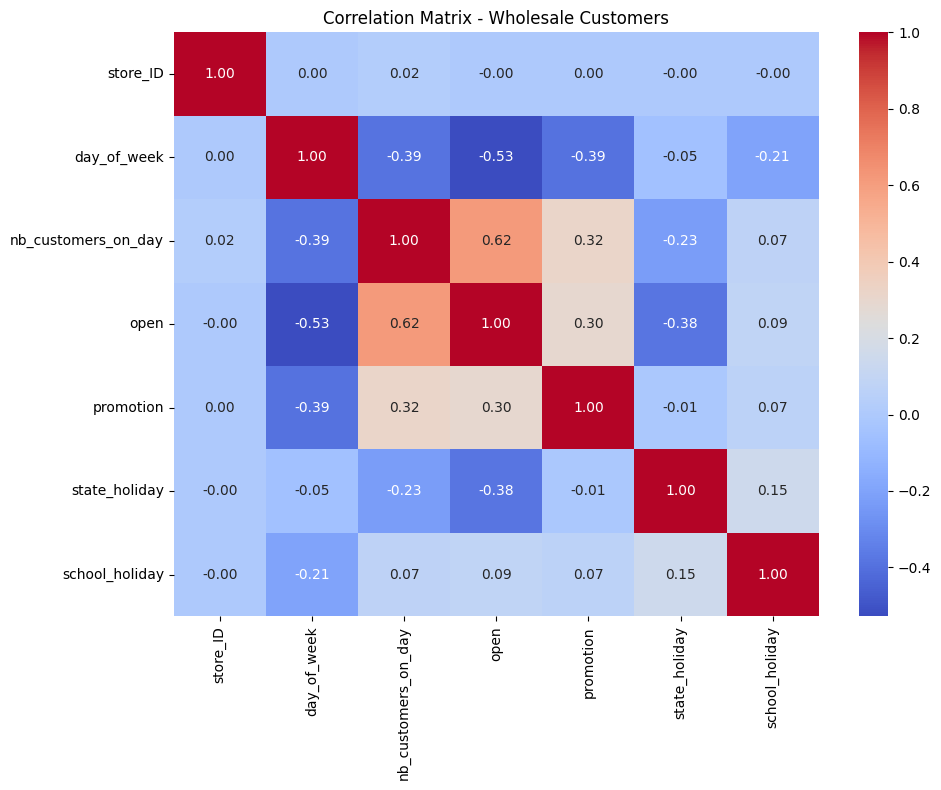

In [55]:
## Data cleaning
correlation_matrix = X_train.corr()

# Visualzing correlation with a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Wholesale Customers')
plt.tight_layout()
plt.show()


In [56]:
# Establish a base model
from sklearn import linear_model

model = linear_model.LinearRegression()

model.fit(X_train, y_train)

print ('Coefficients: ', model.coef_)
print ('Intercept: ', model.intercept_)

Coefficients:  [-1.45042202e-01 -7.79634459e+01  6.06911541e+00  1.47841997e+03
  1.28271457e+03 -7.74346678e+02  6.20650604e+01]
Intercept:  621.014155831379


In [57]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Evaluate
pred = model.predict(X_train)

print("MAE :", mean_absolute_error(y_train, pred))
print("R²  :", r2_score(y_train, pred))



MAE : 980.9018809787468
R²  : 0.8538155233705649


In [58]:
## Check the model on validation set

pred_val = model.predict(X_val)

print("MAE on validation set:", mean_absolute_error(y_val, pred_val))
print("R² on validation set:", r2_score(y_val, pred_val))

MAE on validation set: 982.9261509727799
R² on validation set: 0.8519760005354204


In [59]:
# Test with polynomial Linear Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Polynomial Linear Regression
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", linear_model.LinearRegression())
])
# Train
poly_model.fit(X_train, y_train)

# Predict
y_pred = poly_model.predict(X_train)

# Evaluation
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R² :", r2_score(y_train, y_pred))



MAE: 921.768566480249
R² : 0.869896235217646


In [60]:
## Check the ploynomial model on validation set

pred_val = poly_model.predict(X_val)

print("MAE on validation set:", mean_absolute_error(y_val, pred_val))
print("R² on validation set:", r2_score(y_val, pred_val))

MAE on validation set: 921.522474844909
R² on validation set: 0.8693726389597233


In [61]:
# Polynomial Linear Regression with degree 3
poly_model3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", linear_model.LinearRegression())
])
# Train
poly_model3.fit(X_train, y_train)

# Predict
y_pred = poly_model3.predict(X_train)

# Evaluation
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R² :", r2_score(y_train, y_pred))

MAE: 910.3981245806991
R² : 0.8740854865034006


In [62]:
## Check the ploynomial model on validation set

pred_val3 = poly_model3.predict(X_val)

print("MAE on validation set:", mean_absolute_error(y_val, pred_val3))
print("R² on validation set:", r2_score(y_val, pred_val3))

MAE on validation set: 911.7424294979078
R² on validation set: 0.873220022882957


In [63]:
# Check a different model : KNN

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor

# KNN Pipeline
knn_model = Pipeline([ ("scaler", StandardScaler()), ("knn", KNeighborsRegressor( n_neighbors=3, weights="distance" )) ])

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_train) 

# Evaluate
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R² :", r2_score(y_train, y_pred))



MAE: 17.67088062988756
R² : 0.9995519549530868


In [64]:
## Check the KNN model on validation set

pred_val = knn_model.predict(X_val)

print("MAE on validation set with KNN:", mean_absolute_error(y_val, pred_val))
print("R² on validation set with KNN:", r2_score(y_val, pred_val))

MAE on validation set with KNN: 720.5436984616649
R² on validation set with KNN: 0.8998629977022345


In [65]:
# test the model with XGBoost

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"      # Faster on large datasets
)
preprocess_data
param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,                    # Try 20 random combinations
    scoring="r2",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)
print("Best R2:", search.best_score_)
print("Best Parameters:")
print(search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best R2: 0.937204897403717
Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [66]:
## Check the XGBoost model on validation set

pred_val = model.predict(X_val)

print("MAE on validation set with XGBoost:", mean_absolute_error(y_val, pred_val))
print("R² on validation set with XGBoost:", r2_score(y_val, pred_val))





MAE on validation set with XGBoost: 982.9261509727799
R² on validation set with XGBoost: 0.8519760005354204


In [67]:
## Check the XGBoost model on test set

pred_test = model.predict(X_test)

print("MAE on test set with XGBoost:", mean_absolute_error(y_test, pred_test))
print("R² on test set with XGBoost:", r2_score(y_test, pred_test))

MAE on test set with XGBoost: 981.7590899827904
R² on test set with XGBoost: 0.8511773843706198


In [68]:

## Validation with the best XGBoost model
 
best_model = search.best_estimator_
y_pred = best_model.predict(X_val)
r2 = r2_score(y_val, y_pred)
print(f"Test R²: {r2:.4f}")

Test R²: 0.9388


In [69]:
## Test with the best model till now

y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Test R²: {r2:.4f}")

Test R²: 0.9373


In [ ]:
inference_data = pd.read_csv("../dataset/inference.csv")

display(inference_data.dtypes)

clean_inference_data = preprocess_data(inference_data, "date", "state_holiday")


display(clean_inference_data.dtypes)
display(clean_inference_data.head())


index                  int64
store_ID               int64
day_of_week            int64
date                     str
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday            str
school_holiday         int64
dtype: object

index                  int64
store_ID               int64
day_of_week            int64
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday          int64
school_holiday         int64
dtype: object

,index,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday
0,272371,415,7,0,0,0,0,0
1,558468,27,7,0,0,0,0,0
2,76950,404,3,657,1,1,0,0
3,77556,683,2,862,1,0,0,0
4,456344,920,3,591,1,1,0,0


In [92]:
#clean_inference_data = clean_inference_data.drop(columns="sales")
y = best_model.predict(clean_inference_data)


inference_data["sales"] = y.round() * clean_inference_data["open"].round().astype(int)

display(inference_data.head())


,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,272371,415,7,01/03/2015,0,0,0,0,0,0.0
1,558468,27,7,29/12/2013,0,0,0,0,0,0.0
2,76950,404,3,19/03/2014,657,1,1,0,0,6565.0
3,77556,683,2,29/01/2013,862,1,0,0,0,7413.0
4,456344,920,3,19/03/2014,591,1,1,0,0,5908.0


In [93]:
inference_data.to_csv("../dataset/inference.csv")